In [12]:
import pandas as pd

df = pd.read_csv("data/SampleSuperstore.csv")

df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   str    
 1   Segment       9994 non-null   str    
 2   Country       9994 non-null   str    
 3   City          9994 non-null   str    
 4   State         9994 non-null   str    
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   str    
 7   Category      9994 non-null   str    
 8   Sub-Category  9994 non-null   str    
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), str(8)
memory usage: 1015.1 KB


In [14]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [15]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(17)

In [17]:
# Remove duplicate rows
df = df.drop_duplicates()

# Check again
print("Duplicate rows:", df.duplicated().sum())
print("New Shape:", df.shape)

Duplicate rows: 0
New Shape: (9977, 13)


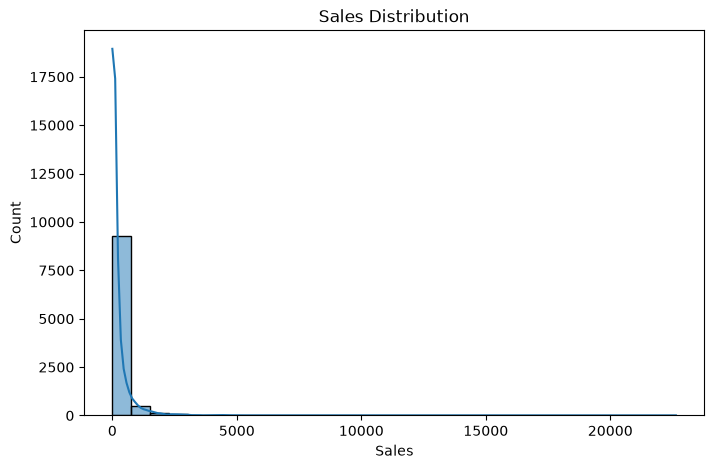

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["Sales"], bins=30, kde=True)

plt.title("Sales Distribution")
plt.show()

Category
Technology         836154.0330
Furniture          741306.3133
Office Supplies    718735.2440
Name: Sales, dtype: float64


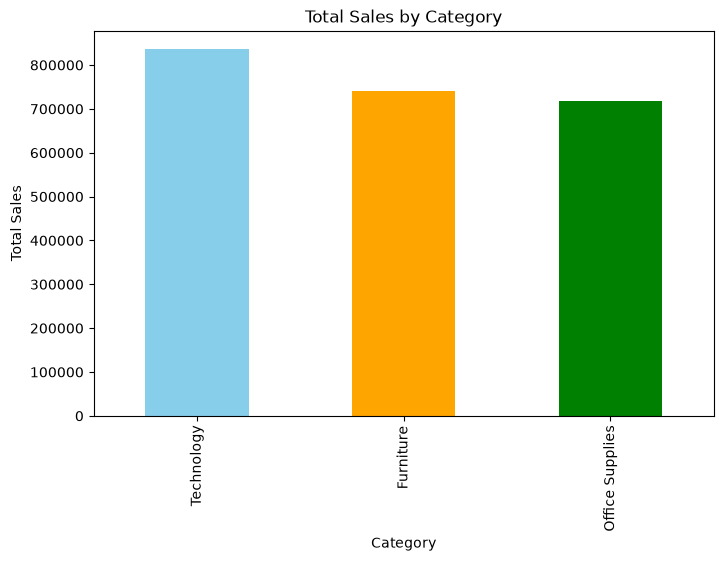

In [19]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

print(category_sales)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
category_sales.plot(kind="bar", color=["skyblue", "orange", "green"])

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

Region
West       725255.6365
East       678435.1960
Central    500782.8528
South      391721.9050
Name: Sales, dtype: float64


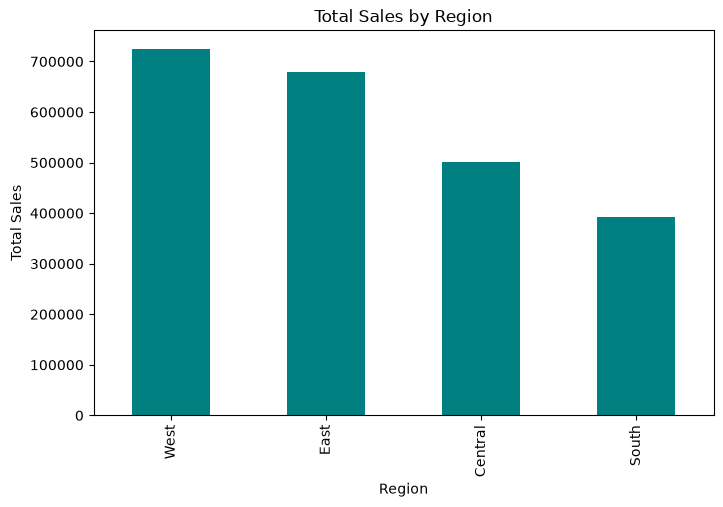

In [20]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

print(region_sales)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
region_sales.plot(kind="bar", color="teal")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

State
California      457576.2715
New York        310827.1510
Texas           170124.5418
Washington      138560.8100
Pennsylvania    116496.3620
Florida          89473.7080
Illinois         80162.5370
Ohio             77976.7640
Michigan         75879.6440
Virginia         70636.7200
Name: Sales, dtype: float64


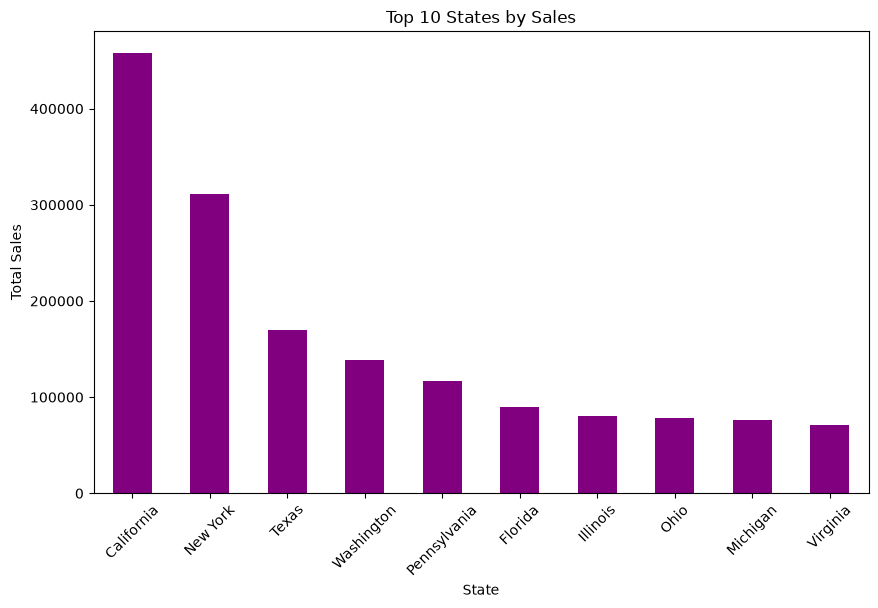

In [21]:
state_sales = df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)

print(state_sales)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
state_sales.plot(kind="bar", color="purple")

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.show()

In [22]:
print(df.columns)

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='str')


In [1]:
profit = df.groupby("Category")["Profit"].sum()

print(profit)

import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
profit.plot(kind="bar", color=["green","orange","blue"])

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

NameError: name 'df' is not defined

In [2]:
import pandas as pd

df = pd.read_csv("data/SampleSuperstore.csv")

df = df.drop_duplicates()

Category
Furniture           18421.8137
Office Supplies    122364.6608
Technology         145454.9481
Name: Profit, dtype: float64


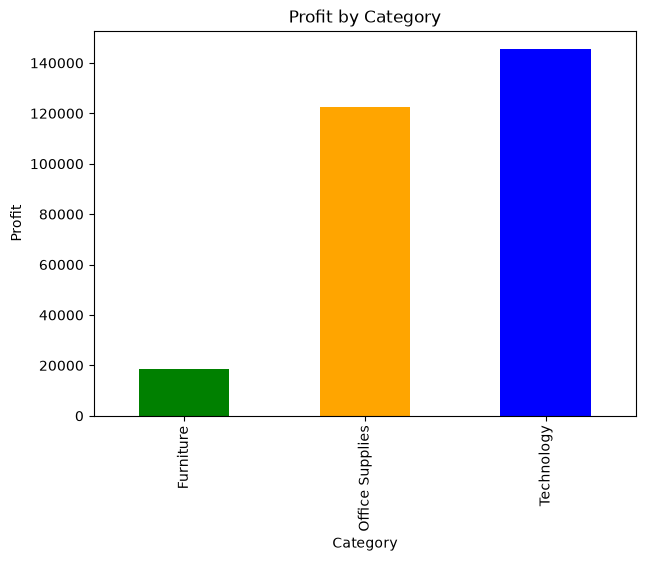

In [3]:
profit = df.groupby("Category")["Profit"].sum()

print(profit)

import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
profit.plot(kind="bar", color=["green","orange","blue"])

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

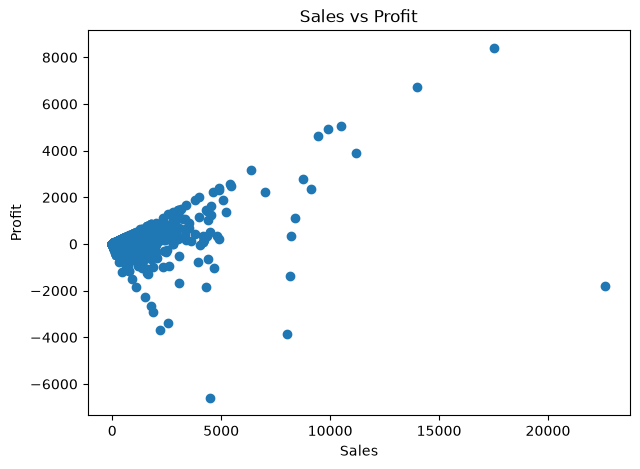

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(df["Sales"], df["Profit"])

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.show()

Ship Mode
Standard Class    5955
Second Class      1943
First Class       1537
Same Day           542
Name: count, dtype: int64


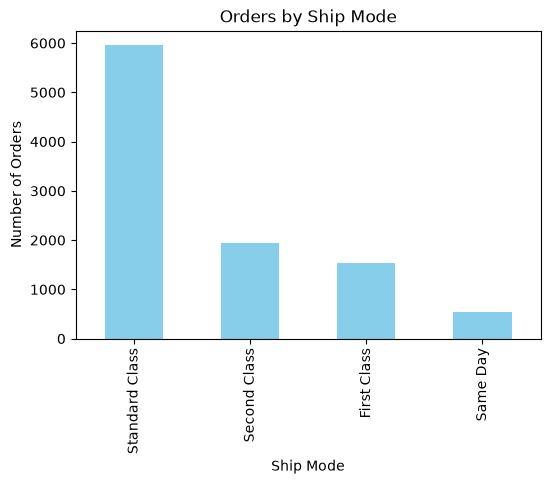

In [5]:
ship = df["Ship Mode"].value_counts()

print(ship)

plt.figure(figsize=(6,4))

ship.plot(kind="bar", color="skyblue")

plt.title("Orders by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Number of Orders")

plt.show()

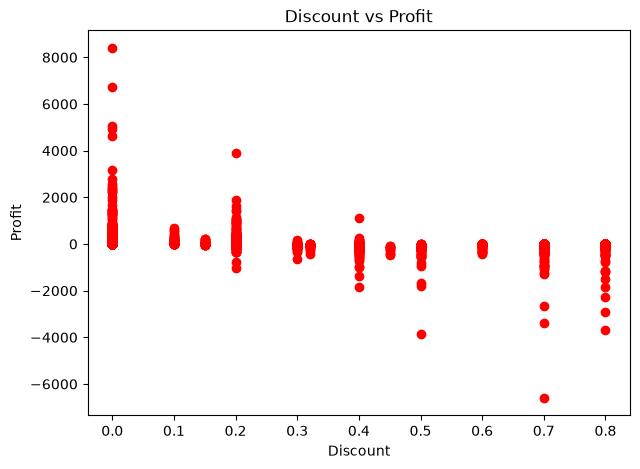

In [6]:
plt.figure(figsize=(7,5))

plt.scatter(df["Discount"], df["Profit"], color="red")

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()